<a href="https://colab.research.google.com/github/Gregory-lab-eng/python_Vistula/blob/main/Cient_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

train file doesn't applicable for our project, case it doesn't have price data


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/content/OnlineRetail.csv', encoding='latin1')


In [5]:
display(df.head())


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [6]:
df.shape

(541909, 8)

In [7]:
list(df)

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

In [8]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [9]:
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [10]:
negatywne = df.query('Quantity <= 0')
display(negatywne)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/2011 9:57,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,12/9/2011 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/2011 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/2011 11:58,1.25,17315.0,United Kingdom


In [11]:
klient_id = 17548.0
produkt_kod = '22556'

historia = df[(df['CustomerID'] == klient_id)]
display(historia[['InvoiceNo', 'InvoiceDate', 'Quantity', 'UnitPrice', 'Description']])

,InvoiceNo,InvoiceDate,Quantity,UnitPrice,Description
235,C536391,12/1/2010 10:24,-12,1.65,PLASTERS IN TIN CIRCUS PARADE
236,C536391,12/1/2010 10:24,-24,0.29,PACK OF 12 PINK PAISLEY TISSUES
237,C536391,12/1/2010 10:24,-24,0.29,PACK OF 12 BLUE PAISLEY TISSUES
238,C536391,12/1/2010 10:24,-24,0.29,PACK OF 12 RED RETROSPOT TISSUES
239,C536391,12/1/2010 10:24,-12,3.45,CHICK GREY HOT WATER BOTTLE
240,C536391,12/1/2010 10:24,-12,1.65,PLASTERS IN TIN VINTAGE PAISLEY
241,C536391,12/1/2010 10:24,-24,1.65,PLASTERS IN TIN SKULLS
165024,550755,4/20/2011 12:01,24,1.25,PACK OF 6 BIRDY GIFT TAGS
165025,550755,4/20/2011 12:01,10,1.65,RIBBON REEL STRIPES DESIGN
165026,550755,4/20/2011 12:01,10,1.65,RIBBON REEL FLORA + FAUNA


In [12]:
import numpy as np

df['Type'] = np.where(df['InvoiceNo'].str.startswith('C', na=False), 'Zwrot', 'Kupno')

display(df.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Type
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,Kupno
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,Kupno
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,Kupno
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,Kupno
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,Kupno


In [13]:
negatywne = df.query('UnitPrice <= 0')

display(negatywne)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Type
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom,Kupno
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom,Kupno
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom,Kupno
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom,Kupno
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom,Kupno
...,...,...,...,...,...,...,...,...,...
536981,581234,72817,NaN,27,12/8/2011 10:33,0.0,NaN,United Kingdom,Kupno
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,12/8/2011 13:58,0.0,NaN,United Kingdom,Kupno
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,12/8/2011 13:58,0.0,NaN,United Kingdom,Kupno
538554,581408,85175,NaN,20,12/8/2011 14:06,0.0,NaN,United Kingdom,Kupno


In [14]:
# Filtrujemy dane
ujemna_cena_z_klientem = df[(df['UnitPrice'] < 0) & (df['CustomerID'].notna())]

# Liczymy ile jest takich wierszy
print(f"Liczba takich wierszy: {len(ujemna_cena_z_klientem)}")

# Wyświetlamy te wiersze
display(ujemna_cena_z_klientem)

Liczba takich wierszy: 0


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Type


In [15]:
df = df[df['UnitPrice'] > 0]

In [16]:
df.shape

(539392, 9)

In [17]:
nan_customers = df[df['CustomerID'].isna()]
display(nan_customers)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Type
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom,Kupno
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom,Kupno
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom,Kupno
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom,Kupno
1447,536544,21790,VINTAGE SNAP CARDS,9,12/1/2010 14:32,1.66,NaN,United Kingdom,Kupno
...,...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,12/9/2011 10:26,4.13,NaN,United Kingdom,Kupno
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,12/9/2011 10:26,4.13,NaN,United Kingdom,Kupno
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,12/9/2011 10:26,4.96,NaN,United Kingdom,Kupno
541539,581498,85174,S/4 CACTI CANDLES,1,12/9/2011 10:26,10.79,NaN,United Kingdom,Kupno


In [18]:

nan_df = df[df['CustomerID'].isna()]

top_descriptions = nan_df['Description'].value_counts().head(10)

top_descriptions_df = top_descriptions.reset_index()
top_descriptions_df.columns = ['Description', 'Count']

print("Top 10 opisów dla transakcji bez CustomerID:")
print(top_descriptions_df)

Top 10 opisów dla transakcji bez CustomerID:
                         Description  Count
0                     DOTCOM POSTAGE    691
1            JUMBO BAG RED RETROSPOT    494
2             JUMBO STORAGE BAG SUKI    414
3  JUMBO SHOPPER VINTAGE RED PAISLEY    388
4         JUMBO BAG WOODLAND ANIMALS    372
5            JUMBO BAG PINK POLKADOT    348
6           RECYCLING BAG RETROSPOT     341
7      RED TOADSTOOL LED NIGHT LIGHT    328
8                 SUKI  SHOULDER BAG    326
9    GREEN REGENCY TEACUP AND SAUCER    322


In [19]:
print(f"Pozostało wierszy z NaN w Description: {df['Description'].isna().sum()}")

Pozostało wierszy z NaN w Description: 0


In [20]:
print("Aktualna liczba brakujących wartości:")
display(df.isnull().sum())

Aktualna liczba brakujących wartości:


,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,132603
Country,0
Type,0


In [21]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Sprawdzamy sumaryczny przychód całego sklepu
total_revenue = df['Revenue'].sum()
print(f"Całkowity przychód w badanym okresie: {total_revenue:,.2f}")

Całkowity przychód w badanym okresie: 9,769,872.05


/tmp/ipykernel_2697/3234679957.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='InvoiceDate')['Revenue'].sum()/1000000


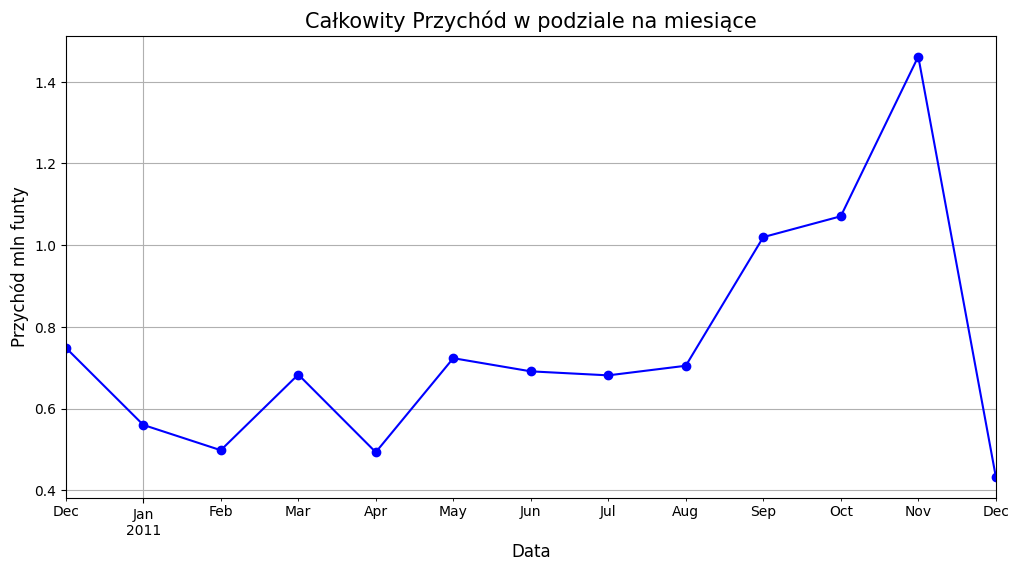

In [22]:
# Konwersja daty (jeśli jeszcze tego nie zrobiłeś)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Grupowanie przychodu po miesiącach
monthly_sales = df.resample('M', on='InvoiceDate')['Revenue'].sum()/1000000

# Wykres liniowy sprzedaży
plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='line', marker='o', color='b')
plt.title('Całkowity Przychód w podziale na miesiące', fontsize=15)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Przychód mln funty', fontsize=12)
plt.grid(True)
plt.show()

/tmp/ipykernel_2697/1814897891.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales_clean = df_filtered.resample('M', on='InvoiceDate')['Revenue'].sum()/1000000


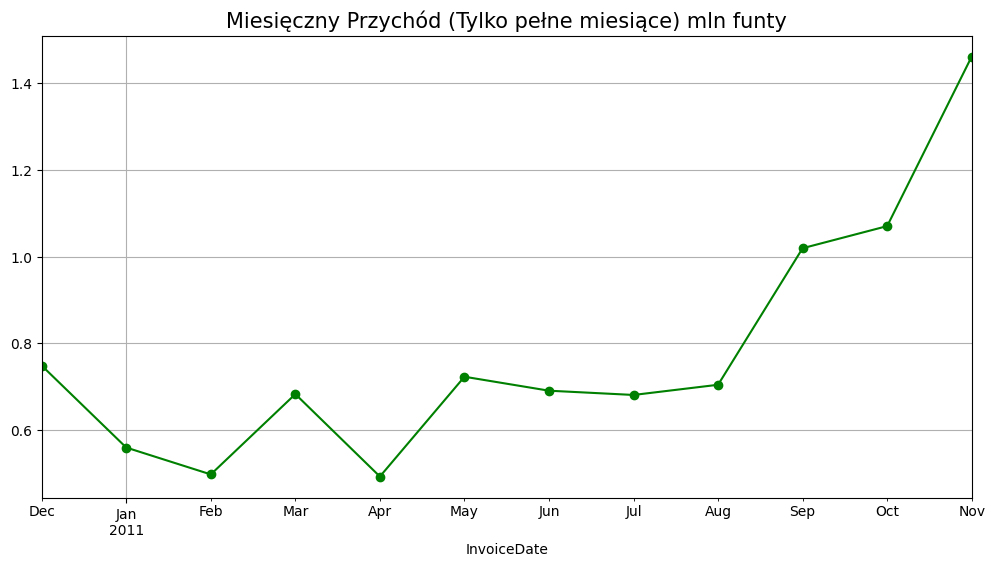

In [23]:
# Filtrujemy dane, zostawiając tylko te sprzed 1 grudnia 2011
df_filtered = df[df['InvoiceDate'] < '2011-12-01']

# Ponownie rysujemy wykres miesięczny dla czystszego trendu
monthly_sales_clean = df_filtered.resample('M', on='InvoiceDate')['Revenue'].sum()/1000000

plt.figure(figsize=(12, 6))
monthly_sales_clean.plot(kind='line', marker='o', color='green')
plt.title('Miesięczny Przychód (Tylko pełne miesiące) mln funty', fontsize=15)
plt.grid(True)
plt.show()

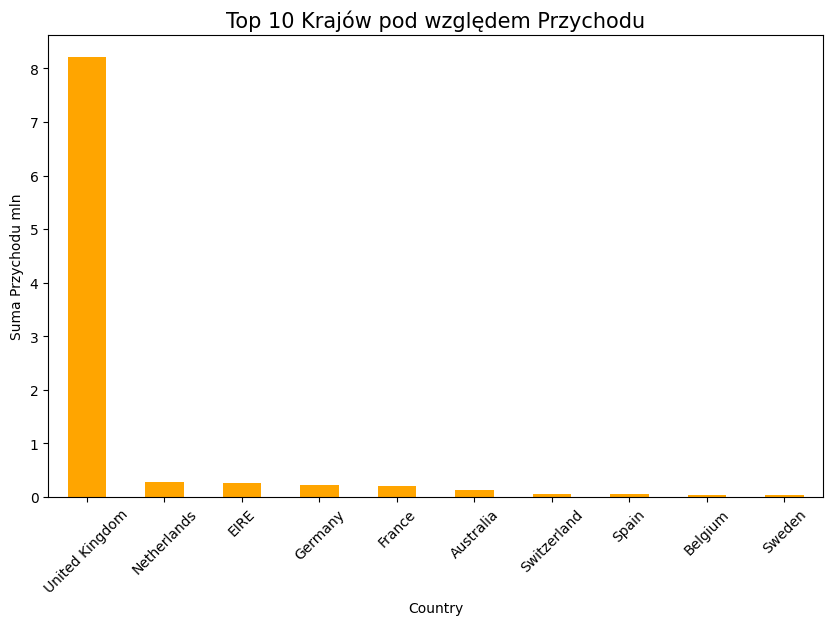

In [24]:
# Grupowanie po kraju i sumowanie przychodu
country_sales = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)/1000000

# Wykres słupkowy dla krajów
plt.figure(figsize=(10, 6))
country_sales.plot(kind='bar', color='orange')
plt.title('Top 10 Krajów pod względem Przychodu', fontsize=15)
plt.ylabel('Suma Przychodu mln')
plt.xticks(rotation=45)
plt.show()

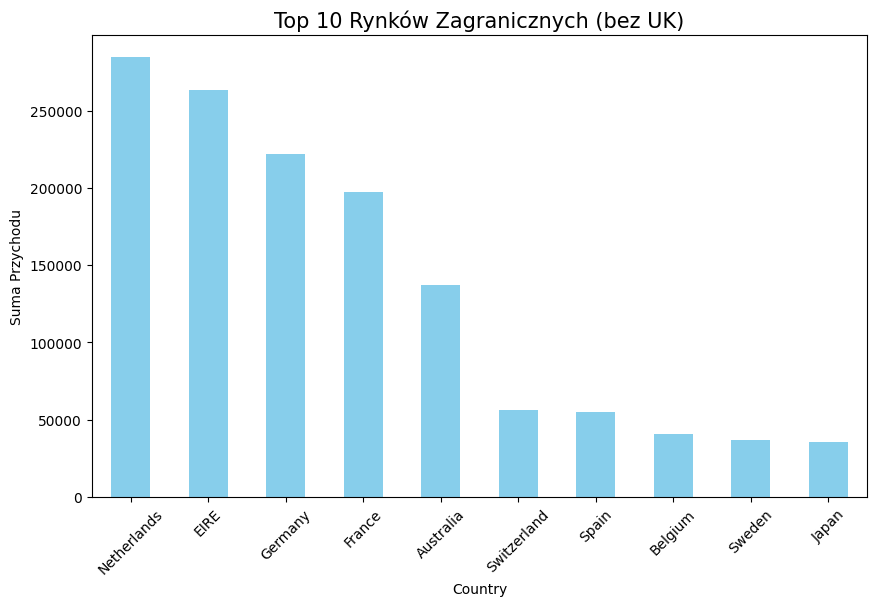

In [25]:
# Wykres bez UK
country_sales_no_uk = df[df['Country'] != 'United Kingdom'].groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
country_sales_no_uk.plot(kind='bar', color='skyblue')
plt.title('Top 10 Rynków Zagranicznych (bez UK)', fontsize=15)
plt.ylabel('Suma Przychodu')
plt.xticks(rotation=45)
plt.show()

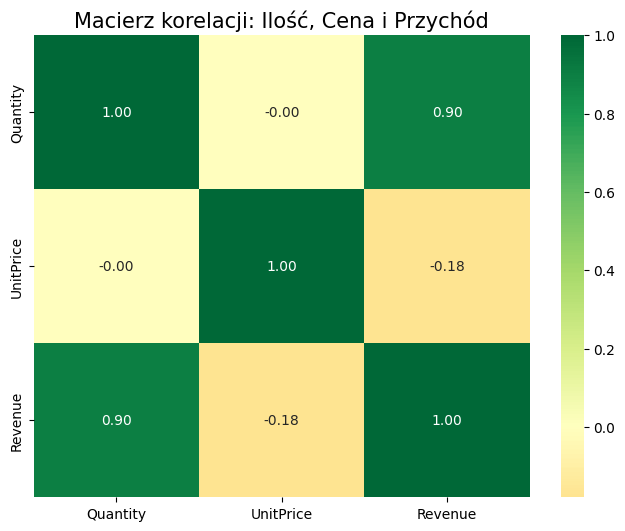

In [26]:
import seaborn as sns

# Wybieramy kolumny do korelacji
corr_data = df[['Quantity', 'UnitPrice', 'Revenue']]

# Obliczamy macierz korelacji (metoda Pearsona)
matrix = corr_data.corr()

# Rysujemy wykres
plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, cmap='RdYlGn', fmt=".2f", center=0)
plt.title('Macierz korelacji: Ilość, Cena i Przychód', fontsize=15)
plt.show()

/tmp/ipykernel_2697/3499974254.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  uk_monthly = df_uk.resample('M', on='InvoiceDate')['Revenue'].sum() / 1_000_000
/tmp/ipykernel_2697/3499974254.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rest_monthly = df_rest.resample('M', on='InvoiceDate')['Revenue'].sum() / 1_000_000


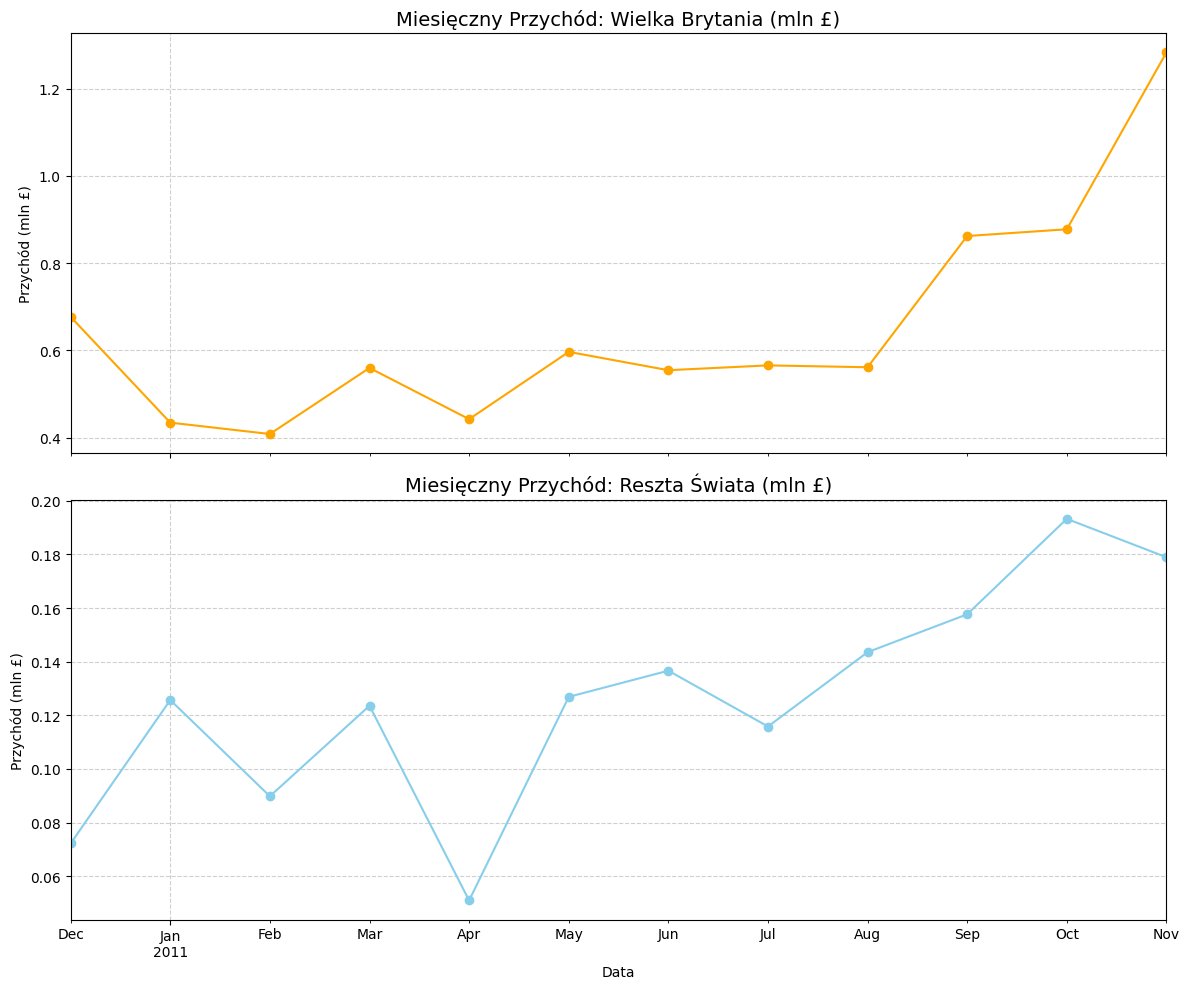

In [27]:


# 1. Podział danych na UK i Resztę Świata (korzystając z przefiltrowanego df_filtered)
df_uk = df_filtered[df_filtered['Country'] == 'United Kingdom']
df_rest = df_filtered[df_filtered['Country'] != 'United Kingdom']

# 2. Resampling miesięczny dla obu grup
uk_monthly = df_uk.resample('M', on='InvoiceDate')['Revenue'].sum() / 1_000_000
rest_monthly = df_rest.resample('M', on='InvoiceDate')['Revenue'].sum() / 1_000_000

# 3. Tworzenie wykresów
fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Wykres dla UK
uk_monthly.plot(kind='line', marker='o', color='orange', ax=ax[0])
ax[0].set_title('Miesięczny Przychód: Wielka Brytania (mln £)', fontsize=14)
ax[0].set_ylabel('Przychód (mln £)')
ax[0].grid(True, linestyle='--', alpha=0.6)

# Wykres dla Reszty Świata
rest_monthly.plot(kind='line', marker='o', color='skyblue', ax=ax[1])
ax[1].set_title('Miesięczny Przychód: Reszta Świata (mln £)', fontsize=14)
ax[1].set_ylabel('Przychód (mln £)')
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.xlabel('Data')
plt.tight_layout()
plt.show()



/tmp/ipykernel_2697/605119389.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Market'] = df_filtered['Country'].apply(lambda x: 'UK' if x == 'United Kingdom' else 'Rest of World')
/tmp/ipykernel_2697/605119389.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  comparison = df_filtered.groupby([pd.Grouper(key='InvoiceDate', freq='M'), 'Market'])['Revenue'].sum() / 1_000_000


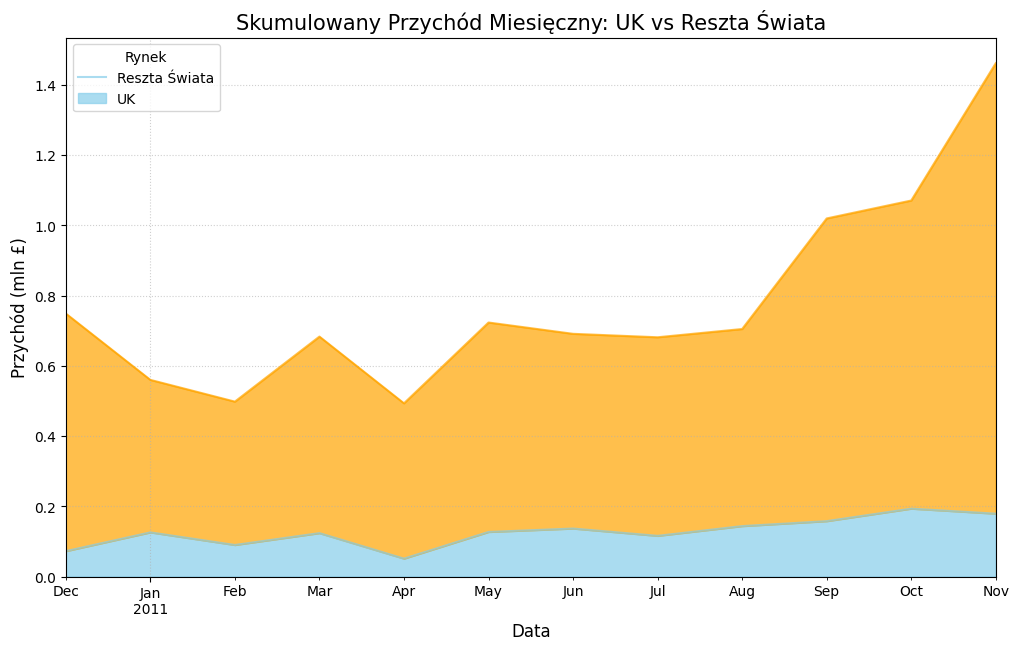

In [28]:
# 1. Tworzymy pomocniczą kolumnę 'Market'
df_filtered['Market'] = df_filtered['Country'].apply(lambda x: 'UK' if x == 'United Kingdom' else 'Rest of World')

# 2. Grupowanie po miesiącu i rynku
comparison = df_filtered.groupby([pd.Grouper(key='InvoiceDate', freq='M'), 'Market'])['Revenue'].sum() / 1_000_000
comparison = comparison.unstack()

# 3. Rysowanie wykresu
plt.figure(figsize=(12, 7))
comparison.plot(kind='area', stacked=True, alpha=0.7, color=['skyblue', 'orange'], ax=plt.gca())

plt.title('Skumulowany Przychód Miesięczny: UK vs Reszta Świata', fontsize=15)
plt.ylabel('Przychód (mln £)', fontsize=12)
plt.xlabel('Data', fontsize=12)
plt.legend(title='Rynek', labels=['Reszta Świata', 'UK']) # Kolejność w legendzie zależy od danych
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

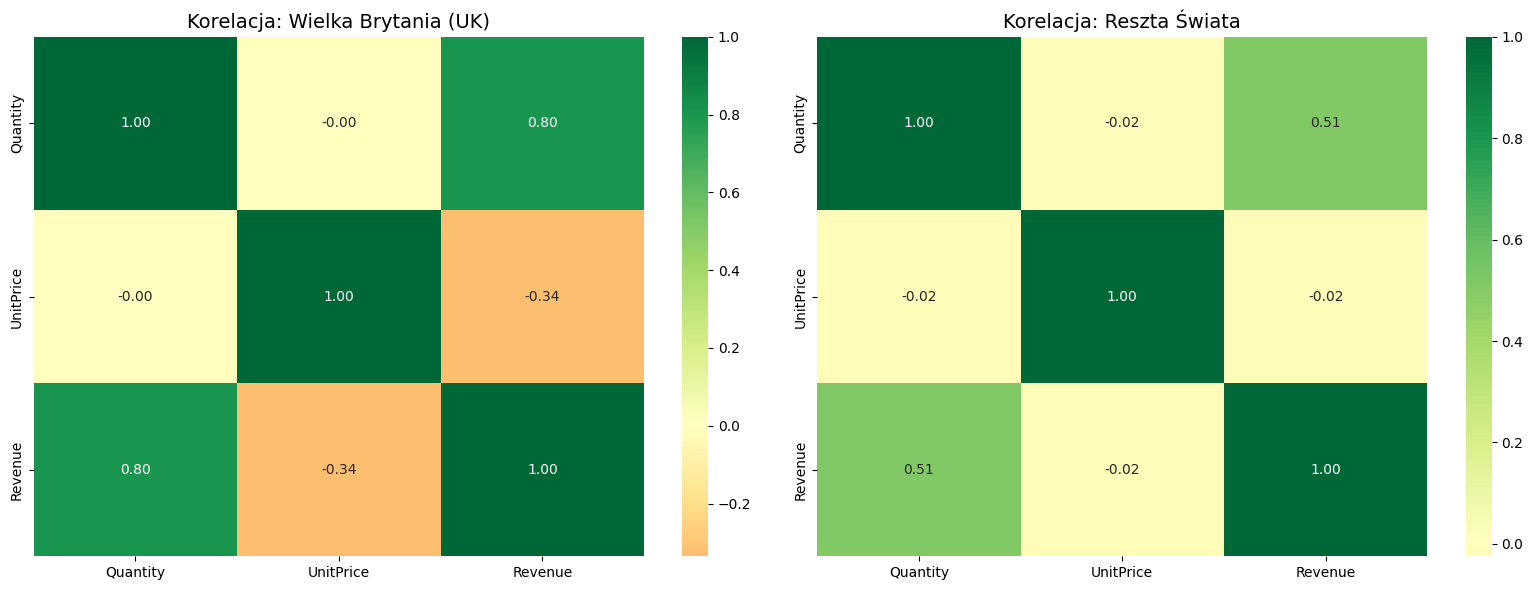

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Przygotowanie danych dla obu rynków
df_uk = df_filtered[df_filtered['Country'] == 'United Kingdom'][['Quantity', 'UnitPrice', 'Revenue']]
df_rest = df_filtered[df_filtered['Country'] != 'United Kingdom'][['Quantity', 'UnitPrice', 'Revenue']]

# 2. Obliczenie macierzy korelacji
matrix_uk = df_uk.corr()
matrix_rest = df_rest.corr()

# 3. Rysowanie dwóch wykresów obok siebie
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Mapa dla UK
sns.heatmap(matrix_uk, annot=True, cmap='RdYlGn', fmt=".2f", center=0, ax=ax[0])
ax[0].set_title('Korelacja: Wielka Brytania (UK)', fontsize=14)

# Mapa dla Reszty Świata
sns.heatmap(matrix_rest, annot=True, cmap='RdYlGn', fmt=".2f", center=0, ax=ax[1])
ax[1].set_title('Korelacja: Reszta Świata', fontsize=14)

plt.tight_layout()
plt.show()

In [30]:
# 1. Definiujemy słowa kluczowe do usunięcia (Postage, DOTCOM POSTAGE, itp.)
# Najbezpieczniej odfiltrować wszystko, co zawiera słowo 'POSTAGE'
df_no_postage = df_filtered[~df_filtered['Description'].str.contains('POSTAGE', case=False, na=False)]

# 2. Ponowne obliczenie Top 10 dla obu rynków bez kosztów logistyki
def get_clean_top_10(data, market_name):
    total_revenue = data['Revenue'].sum()
    top_10 = data.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
    top_10_df = top_10.reset_index()
    top_10_df['Percentage'] = (top_10_df['Revenue'] / total_revenue) * 100
    print(f"--- TOP 10 : {market_name} ---")
    print(top_10_df)
    print(f"Suma udziału Top 10: {top_10_df['Percentage'].sum():.2f}%\n")
    return top_10_df

# Podział i uruchomienie
df_uk_clean = df_no_postage[df_no_postage['Country'] == 'United Kingdom']
df_rest_clean = df_no_postage[df_no_postage['Country'] != 'United Kingdom']

top_10_uk_clean = get_clean_top_10(df_uk_clean, "WIELKA BRYTANIA")
top_10_rest_clean = get_clean_top_10(df_rest_clean, "RESZTA ŚWIATA")

--- TOP 10 : WIELKA BRYTANIA ---
                          Description    Revenue  Percentage
0            REGENCY CAKESTAND 3 TIER  129971.67    1.702039
1  WHITE HANGING HEART T-LIGHT HOLDER   92039.05    1.205294
2                       PARTY BUNTING   91662.45    1.200362
3             JUMBO BAG RED RETROSPOT   82460.10    1.079853
4     PAPER CHAIN KIT 50'S CHRISTMAS    55035.18    0.720711
5       ASSORTED COLOUR BIRD ORNAMENT   52499.41    0.687504
6                       CHILLI LIGHTS   50352.87    0.659394
7      PICNIC BASKET WICKER 60 PIECES   39619.50    0.518836
8             JUMBO BAG PINK POLKADOT   36870.10    0.482831
9                      SPOTTY BUNTING   35979.06    0.471163
Suma udziału Top 10: 8.73%

--- TOP 10 : RESZTA ŚWIATA ---
                           Description   Revenue  Percentage
0             REGENCY CAKESTAND 3 TIER  28887.60    1.992119
1                   RABBIT NIGHT LIGHT  25449.20    1.755004
2  ROUND SNACK BOXES SET OF4 WOODLAND   17985.40    1.

In [31]:
# 1. Obliczamy wartość każdego unikalnego zamówienia (InvoiceNo)
order_values = df_filtered.groupby(['InvoiceNo', 'Market'])['Revenue'].sum().reset_index()

# 2. Obliczamy średnią wartość koszyka (AOV) dla obu rynków
aov_market = order_values.groupby('Market')['Revenue'].mean()

# 3. Dodatkowo sprawdźmy medianę (często lepsza, gdy są "skrajne" zamówienia)
median_order = order_values.groupby('Market')['Revenue'].median()

print("--- ŚREDNIA WARTOŚĆ ZAMÓWIENIA (AOV) ---")
print(aov_market)
print("\n--- MEDIANA WARTOŚCI ZAMÓWIENIA ---")
print(median_order)

--- ŚREDNIA WARTOŚĆ ZAMÓWIENIA (AOV) ---
Market
Rest of World    655.280705
UK               381.168432
Name: Revenue, dtype: float64

--- MEDIANA WARTOŚCI ZAMÓWIENIA ---
Market
Rest of World    329.655
UK               232.600
Name: Revenue, dtype: float64


In [32]:
# 1. Liczymy liczbę zamówień dla każdego klienta
customer_orders = df_filtered.groupby(['CustomerID', 'Market'])['InvoiceNo'].nunique().reset_index()

# 2. Klasyfikujemy klientów: Powracający (więcej niż 1 zamówienie) vs Jednorazowi
customer_orders['Type'] = customer_orders['InvoiceNo'].apply(lambda x: 'Powracający' if x > 1 else 'Jednorazowy')

# 3. Podsumowanie liczby klientów wg typu i rynku
loyalty_summary = customer_orders.groupby(['Market', 'Type'])['CustomerID'].count().unstack()

# 4. Obliczamy przychód generowany przez obie grupy
customer_revenue = df_filtered.groupby('CustomerID')['Revenue'].sum().reset_index()
customer_revenue = customer_revenue.merge(customer_orders[['CustomerID', 'Type', 'Market']], on='CustomerID')

revenue_summary = customer_revenue.groupby(['Market', 'Type'])['Revenue'].sum().unstack()

print("--- LICZBA KLIENTÓW (Jednorazowi vs Powracający) ---")
print(loyalty_summary)
print("\n--- PRZYCHÓD WG TYPU KLIENTA mln funtow ---")
print(revenue_summary / 1_000_000)

--- LICZBA KLIENTÓW (Jednorazowi vs Powracający) ---
Type           Jednorazowy  Powracający
Market                                 
Rest of World          126          289
UK                    1229         2686

--- PRZYCHÓD WG TYPU KLIENTA mln funtow ---
Type           Jednorazowy  Powracający
Market                                 
Rest of World     0.077993     1.409614
UK                0.370561     6.099392


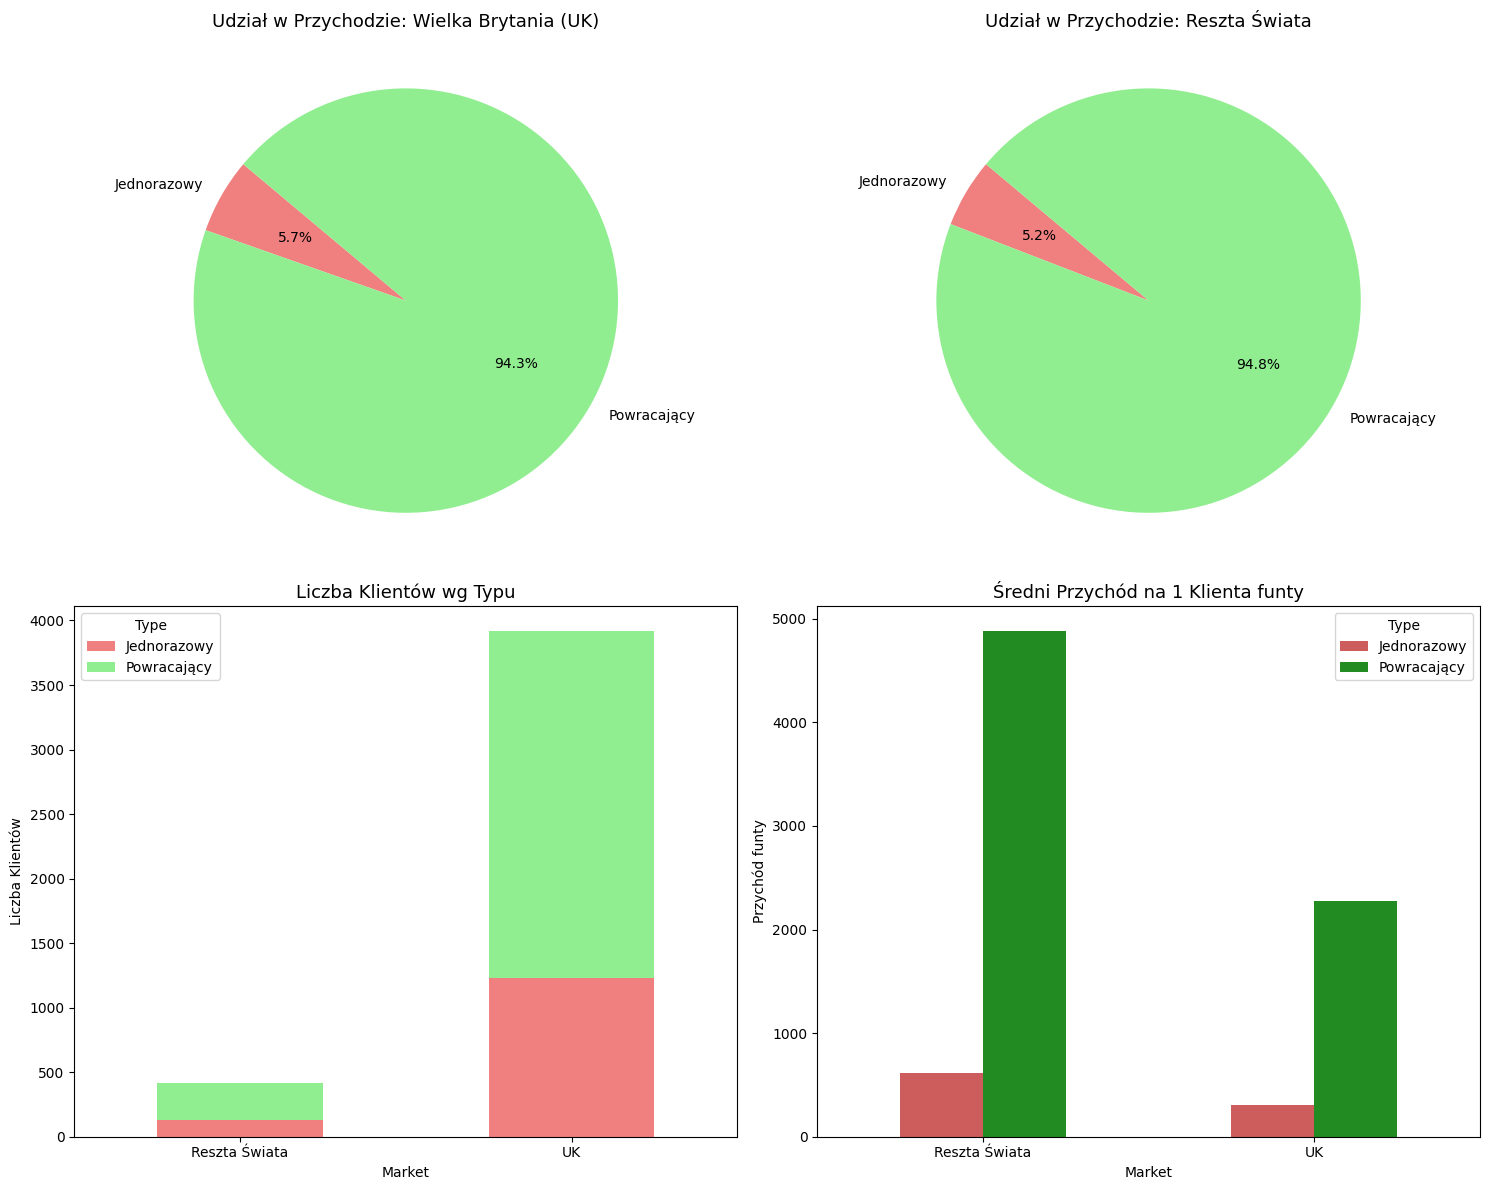

In [33]:
import matplotlib.pyplot as plt

# 1. Przygotowanie danych do wykresów kołowych (Revenue)
uk_rev = revenue_summary.loc['UK']
rest_rev = revenue_summary.loc['Rest of World']

# 2. Tworzenie subplots (2x2)
fig, ax = plt.subplots(2, 2, figsize=(15, 12))

# Wykres kołowy: Przychód UK
ax[0, 0].pie(uk_rev, labels=uk_rev.index, autopct='%1.1f%%', colors=['lightcoral', 'lightgreen'], startangle=140)
ax[0, 0].set_title('Udział w Przychodzie: Wielka Brytania (UK)', fontsize=13)

# Wykres kołowy: Przychód Reszta Świata
ax[0, 1].pie(rest_rev, labels=rest_rev.index, autopct='%1.1f%%', colors=['lightcoral', 'lightgreen'], startangle=140)
ax[0, 1].set_title('Udział w Przychodzie: Reszta Świata', fontsize=13)

# Wykres słupkowy: Liczba klientów (Lojalność)
loyalty_summary.plot(kind='bar', stacked=True, ax=ax[1, 0], color=['lightcoral', 'lightgreen'])
ax[1, 0].set_title('Liczba Klientów wg Typu', fontsize=13)
ax[1, 0].set_ylabel('Liczba Klientów')
ax[1, 0].set_xticklabels(['Reszta Świata', 'UK'], rotation=0)

# Wykres słupkowy: Średni przychód na typ klienta
rev_per_cust = revenue_summary / loyalty_summary
rev_per_cust.plot(kind='bar', ax=ax[1, 1], color=['indianred', 'forestgreen'])
ax[1, 1].set_title('Średni Przychód na 1 Klienta funty', fontsize=13)
ax[1, 1].set_ylabel('Przychód funty')
ax[1, 1].set_xticklabels(['Reszta Świata', 'UK'], rotation=0)

plt.tight_layout()
plt.show()

In [34]:
import pandas as pd
from datetime import timedelta

# Zakładamy, że df_filtered to Twoje oczyszczone dane
# Ustalamy datę "dzisiejszą" jako dzień po ostatniej transakcji w zbiorze
snapshot_date = df_filtered['InvoiceDate'].max() + timedelta(days=1)

# Agregacja danych na poziomie klienta
rfm = df_filtered.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                 # Frequency
    'Revenue': 'sum'                                        # Monetary
})

# Zmiana nazw kolumn
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Podział na kwantyle (skala 1-5, gdzie 5 to wynik najlepszy)
# Uwaga: Dla Recency mniejsza liczba dni jest lepsza, więc etykiety są odwrotnie
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# Połączony wynik RFM
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

print(rfm.head())

            Recency  Frequency  Monetary R_score F_score M_score RFM_Score
CustomerID                                                                
12346.0         317          2      0.00       1       2       1       121
12347.0          31          6   4085.18       4       4       5       445
12348.0          67          4   1797.24       3       4       4       344
12349.0          10          1   1757.55       5       1       4       514
12350.0         302          1    334.40       1       1       2       112


In [35]:
def segment_rfm(df):
    r = int(df['R_score'])
    f = int(df['F_score'])

    if r >= 4 and f >= 4:
        return 'Champions (Mistrzowie)'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers (Lojalni)'
    elif r >= 4 and f <= 2:
        return 'New Customers (Nowi)'
    elif r <= 2:
        return 'At Risk / Hibernating (Zagrożeni)'
    else:
        return 'Others (Pozostali)'

rfm['Segment'] = rfm.apply(segment_rfm, axis=1)

In [36]:
# Liczba klientów w segmentach
segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

# Procent udziału w liczbie klientów
total_customers = len(rfm)
segment_counts['Customer_Percentage'] = (segment_counts['Count'] / total_customers) * 100

# Udział w przychodzie (Monetary)
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().reset_index()
total_revenue = rfm['Monetary'].sum()
segment_revenue['Revenue_Percentage'] = (segment_revenue['Monetary'] / total_revenue) * 100

# Łączymy wyniki
final_rfm = segment_counts.merge(segment_revenue, on='Segment')
print(final_rfm[['Segment', 'Count', 'Customer_Percentage', 'Revenue_Percentage']])

                             Segment  Count  Customer_Percentage  \
0  At Risk / Hibernating (Zagrożeni)   1716            39.630485   
1             Champions (Mistrzowie)   1101            25.427252   
2          Loyal Customers (Lojalni)    796            18.383372   
3                 Others (Pozostali)    364             8.406467   
4               New Customers (Nowi)    353             8.152425   

   Revenue_Percentage  
0           13.923511  
1           68.898047  
2           13.385281  
3            1.953338  
4            1.839823  


In [48]:
import plotly.express as px

# Tworzenie wykresu Treemap
fig = px.treemap(final_rfm,
                 path=['Segment'],
                 values='Count',
                 color='Count',
                 color_continuous_scale='RdYlGn_r',
                 title='Segmentacja RFM: Liczebność grup klientów')

# DODANIE PROCENTÓW: label (nazwa), value (liczba), percent root (procent z całości)
fig.update_traces(textinfo="label+value+percent root")

# Estetyka
fig.update_layout(title_x=0.5)

fig.show()

In [42]:


import plotly.express as px

# Zakładamy, że masz tabelę final_rfm z kolumnami: 'Segment', 'Count', 'Monetary'
# Jeśli wcześniej łączyłeś grupy, użyj tabeli po konsolidacji

fig = px.treemap(final_rfm,
                 path=['Segment'],
                 values='Monetary',           # WIELKOŚĆ: Teraz kasa decyduje o rozmiarze kafelka
                 color='Count',              # KOLOR: Liczba klientów w grupie
                 color_continuous_scale='RdYlGn_r',
                 title='Segmentacja RFM: Wartość Segmentu (Wielkość) vs Liczebność (Kolor)')

# Dodajemy etykiety, aby wewnątrz kafelka było widać kwoty
fig.update_traces(textinfo="label+value+percent parent")
fig.update_layout(title_x=0.5)

fig.show()

In [ ]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# 1. Wykres 1: Wielkość grupy (ilu jest klientów)
fig1 = px.treemap(final_rfm,
                  path=['Segment'],
                  values='Count',
                  color='Count',
                  color_continuous_scale='Blues',
                  title='WIELKOŚĆ GRUPY (Liczba klientów w segmencie)')

# 2. Wykres 2: Przychod grupy (ile pieniędzy zostawili)
fig2 = px.treemap(final_rfm,
                  path=['Segment'],
                  values='Monetary',
                  color='Monetary',
                  color_continuous_scale='Greens',
                  title='PRZYCHÓD GRUPY (Łączna wartość zakupów)')

fig1.show()
fig2.show()

In [ ]:
import plotly.express as px

# 1. Resetujemy indeks, aby CustomerID stało się zwykłą kolumną
rfm_reset = rfm.reset_index()

# 2. Agregujemy dane na poziomie segmentu
segment_analysis = rfm_reset.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'sum',
    'CustomerID': 'count'  # Teraz zadziała, bo CustomerID jest kolumną
}).reset_index()

# 3. Obliczamy % udziału w przychodzie dla każdego segmentu
total_revenue = segment_analysis['Monetary'].sum()
segment_analysis['Revenue_Share_%'] = (segment_analysis['Monetary'] / total_revenue) * 100

# 4. Tworzymy wykres bąbelkowy
fig = px.scatter(segment_analysis,
                 x="Recency",
                 y="Frequency",
                 size="Monetary",           # Wielkość bąbla = łączna kasa grupy
                 color="Segment",           # Kolor = nazwa grupy
                 hover_name="Segment",
                 hover_data={'Revenue_Share_%': ':.2f', 'CustomerID': True}, # Dodatkowe info w dymku
                 text="Segment",            # Etykieta na bąblu
                 size_max=80,
                 title="Mapa Segmentów RFM (Wielkość = Przychód grupy)")

# Odwracamy oś X (im mniejsze Recency, tym lepiej)
fig.update_xaxes(autorange="reversed", title="Dni od ostatniego zakupu (Średnio)")
fig.update_yaxes(title="Częstotliwość zakupów (Średnio)")
fig.show()

In [ ]:
import plotly.express as px

# 1. Resetujemy indeks i agregujemy (pamiętaj o 'CustomerID': 'count')
rfm_reset = rfm.reset_index()
segment_analysis = rfm_reset.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'sum',
    'CustomerID': 'count'
}).reset_index()

# 2. Tworzymy czytelną etykietę tekstową dla każdego bąbla
segment_analysis['Label'] = segment_analysis['Segment'] + "<br>N=" + segment_analysis['CustomerID'].astype(str)

# 3. Wykres bąbelkowy z widoczną liczbą klientów
fig = px.scatter(segment_analysis,
                 x="Recency",
                 y="Frequency",
                 size="Monetary",
                 color="CustomerID",          # Kolor pokazuje liczebność (skala)
                 color_continuous_scale='Viridis',
                 text="Label",                # Wyświetlamy Nazwę i N (liczbę osób)
                 hover_name="Segment",
                 size_max=70,
                 title="Segmenty RFM: Pozycja (Behawior), Wielkość (Kasa), Etykieta (Liczba osób)")

# 4. Estetyka i odwrócenie osi Recency
fig.update_traces(textposition='top center')
fig.update_xaxes(autorange="reversed", title="Średnie Recency (dni)")
fig.update_yaxes(title="Średnia Częstotliwość")
fig.show()

In [ ]:
import plotly.express as px

# 1. Agregacja danych: Oś X (Frequency), Oś Y (Liczba klientów), Wielkość (Monetary)
rfm_reset = rfm.reset_index()
segment_analysis = rfm_reset.groupby('Segment').agg({
    'Frequency': 'mean',        # Średnia częstotliwość w grupie
    'Monetary': 'sum',          # Łączny przychód grupy
    'CustomerID': 'count'       # Liczba klientów (nasza nowa Oś Y)
}).reset_index()

# 2. Etykieta z konkretnymi danymi
segment_analysis['Label'] = (
    segment_analysis['Segment'] +
    "<br>Klienci: " + segment_analysis['CustomerID'].astype(str) +
    "<br>Suma: " + segment_analysis['Monetary'].map('{:,.0f} £'.format)
)

# 3. Wykres: X = Frequency, Y = Liczba klientów, Size = Monetary
fig = px.scatter(segment_analysis,
                 x="Frequency",
                 y="CustomerID",
                 size="Monetary",           # Wielkość bąbla to łączna kasa
                 color="Segment",           # Kolory dla czytelności segmentów
                 text="Label",
                 size_max=80,
                 title="Analiza Segmentów: Częstotliwość vs Liczebność (Wielkość = Łączny Przychód)")

# 4. Kosmetyka wykresu
fig.update_traces(textposition='top center')
fig.update_xaxes(title="Średnia liczba zamówień (Frequency)")
fig.update_yaxes(title="Liczba klientów w segmencie")
fig.show()

In [ ]:
import plotly.express as px

# 1. Łączymy segmenty 'New Customers (Nowi)' oraz 'Others (Pozostali)' w jeden
rfm_reset = rfm.reset_index()
rfm_reset['Segment'] = rfm_reset['Segment'].replace({
    'New Customers (Nowi)': 'Nowi i Pozostali',
    'Others (Pozostali)': 'Nowi i Pozostali'
})

# 2. Ponowna agregacja danych dla połączonych grup
segment_analysis = rfm_reset.groupby('Segment').agg({
    'Frequency': 'mean',        # Średnia częstotliwość
    'Monetary': 'sum',          # Łączny przychód grupy
    'CustomerID': 'count'       # Liczba klientów (Oś Y)
}).reset_index()

# 3. Przygotowanie czytelnej etykiety
segment_analysis['Label'] = (
    segment_analysis['Segment'] +
    "<br>Klienci: " + segment_analysis['CustomerID'].astype(str) +
    "<br>Suma: " + segment_analysis['Monetary'].map('{:,.0f} £'.format)
)

# 4. Wykres: X = Frequency, Y = Liczba klientów, Size = Monetary
fig = px.scatter(segment_analysis,
                 x="Frequency",
                 y="CustomerID",
                 size="Monetary",
                 color="Segment",
                 text="Label",
                 size_max=85,
                 title="Skonsolidowana Analiza FM: Częstotliwość vs Liczebność")

# 5. Kosmetyka
fig.update_traces(textposition='top center')
fig.update_xaxes(title="Średnia liczba zamówień (Frequency)")
fig.update_yaxes(title="Liczba klientów w segmencie")
fig.show()